<a href="https://colab.research.google.com/github/keirvirtudez/CPE-018-CPE31S2/blob/main/VIRTUDEZ_Activity_6_Face_Detection_using_OpenCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision
1st Semester | AY 2023-2024
<u>**ACTIVITY NO.** | **TITLE**
**Name** | VIRTUDEZ, RENMAR KEIR F.
**Section** | CPE31S2
**Date Performed**: | 2/24/2026
**Date Submitted**: | 2/24/2026
**Instructor**: | Engr. Maria Rizette Sayo


## 1. Objectives

This activity aims to allow students to perform face detection on still images and videos using Haar cascades.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Utilize OpenCV to detect faces in still images and videos.
* Demonstrate the use of Haar-like features for detection of other human features.

## 3. Procedures and Outputs

Contrary to initial assumptions, conducting face detection on a static image and a video stream shares a remarkable similarity. Essentially, the latter is merely a sequential rendition of the former: when detecting faces in videos, it essentially involves applying face detection to every individual frame obtained from the camera feed. Of course, video face detection introduces additional elements like tracking, which aren't relevant to static images. Nevertheless, it's valuable to recognize that the fundamental principles behind both processes remain consistent.

### Performing face detection on still image

The first and most basic way to perform face detection is to load an image and detect faces in it. To make the result visually meaningful, we will draw rectangles around faces on the original image.

**Before implementing the code below**, check the contents of the `cv2.CascadeClassifier()` function. Provide an explanation of the function, its parameters before running the code below.

In [ ]:
# Make sure that for this activity, you have downloaded the
# file indicated below from the resource linked in the instructional materials
# in the module.

import cv2
from google.colab.patches import cv2_imshow

picPath = '/content/drive/MyDrive/EMTECH/titovic,andjoey.jpg'
haarPath = '/content/haarcascade_frontalface_default.xml'

def faceDetect(picPath):
  face_cascade = cv2.CascadeClassifier(haarPath)

  img = cv2.imread(picPath)
  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  faces = face_cascade.detectMultiScale(gray, 1.3, 5)

  for (x, y, w, h) in faces:
    img = cv2.rectangle(img, (x, y), (x+w, y+h), (255,0,0), 2)

  cv2_imshow(img)

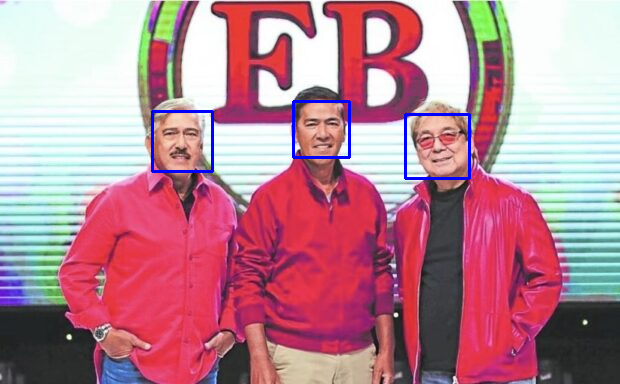

In [ ]:
faceDetect(picPath)

**Analysis**:
- Based on your earlier analysis, where do you think the face detection works in the line of code above?
- Provide an analysis of the parameters of the `detectMultiScale` method.
- Change the color of the border of the detected faces to red.
- Are you able to make the borders thicker? Demonstrate.

### Performing face detection on video

**Step 1**: Create a file called face_detection.py and include the following codes.

In [ ]:
import cv2

**Step 2:** After this, we declare a method, `detect()`, which will perform face detection.

In [ ]:
import cv2
import os
import requests
from google.colab.patches import cv2_imshow

face_cascade_url = 'https://raw.githubusercontent.com/opencv/opencv/4.x/data/haarcascades/haarcascade_frontalface_default.xml'
cascade_file = 'haarcascade_frontalface_default.xml'

if not os.path.exists(cascade_file):
    r = requests.get(face_cascade_url)
    with open(cascade_file, 'wb') as f:
        f.write(r.content)

**Step 3:** The first thing we need to do inside the detect() method is to load the Haar cascade files so that OpenCV can operate face detection. As we copied
the cascade files in the local `cascades/` folder, we can use a relative path. Then, we open a VideoCapture object (the camera feed). The VideoCapture  constructor takes a parameter, which indicates the camera to be used; zero indicates the first camera available.

In [ ]:
video_path = '/content/drive/MyDrive/EMTECH/Pedro Pascal Laughing GIF by Crafture.gif'
cap = cv2.VideoCapture(video_path)

face_cascade = cv2.CascadeClassifier(cascade_file)

if not cap.isOpened():
    print("Error: Could not open video file.")

**Step 4:** Next up, we capture a frame. The read() method returns two values: a Boolean indicating the success of the frame read operation, and the frame
itself. We capture the frame, and then we convert it to grayscale. This is a necessary operation, because face detection in OpenCV happens in the grayscale color space:

**Step 5:** Much like the single still image example, we call detectMultiScale on the grayscale version of the frame.

**Step 6:** Here we have a further step compared to the still image example: we create a region of interest corresponding to the face rectangle, and within this rectangle, we operate "eye detection". This makes sense as you wouldn't want to go looking for eyes outside a face (well, for human beings at least!).

**Step 7:** Again, we loop through the resulting eye tuples and draw green rectangles around them.

Displaying frame 0:


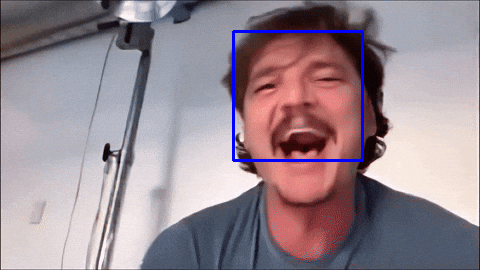

Displaying frame 30:


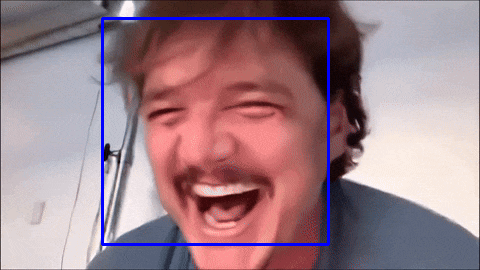

Displaying frame 60:


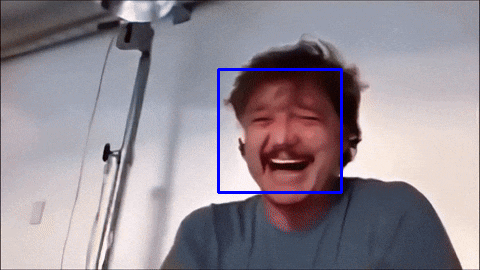

Displaying frame 90:


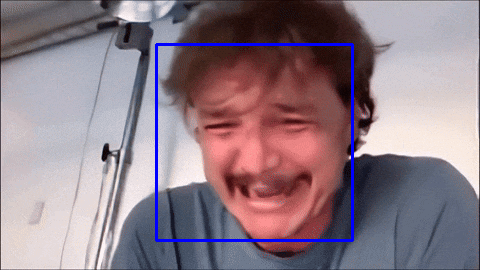

Displaying frame 120:


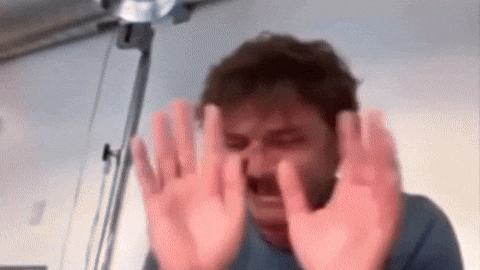

Displaying frame 150:


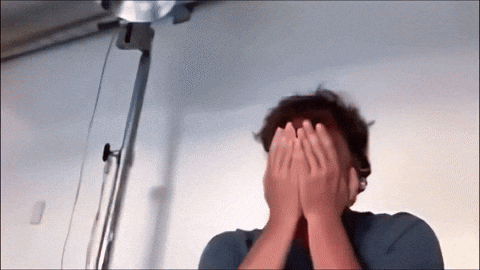

Video processing complete.


In [ ]:
frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

    if frame_count % 30 == 0:
        print(f"Displaying frame {frame_count}:")
        cv2_imshow(frame)

    frame_count += 1

cap.release()
print("Video processing complete.")

**Provide the following**:
- Screenshot of the output for the working code once you've put it all together.
- Summary of the steps you've performed along with observations.

## 4. Supplementary Activity

In your Cameo project, include real-time face detection using Haar cascade. Show screenshots of the working demonstration for this supplementary activity.

Additionally, implement similar steps to detect a smile using Haar cascades.

In [ ]:
import cv2
import requests
import os
from google.colab.patches import cv2_imshow

models = {
    "face.xml": "https://raw.githubusercontent.com/opencv/opencv/4.x/data/haarcascades/haarcascade_frontalface_default.xml",
    "eye.xml": "https://raw.githubusercontent.com/opencv/opencv/4.x/data/haarcascades/haarcascade_eye.xml",
    "smile.xml": "https://raw.githubusercontent.com/opencv/opencv/4.x/data/haarcascades/haarcascade_smile.xml"
}

for name, url in models.items():
    if not os.path.exists(name):
        r = requests.get(url)
        with open(name, 'wb') as f:
            f.write(r.content)

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

video_source = '/content/drive/MyDrive/EMTECH/IMG_5657.MOV'
camera = cv2.VideoCapture(video_source)

fps = int(camera.get(cv2.CAP_PROP_FPS))
if fps == 0: fps = 30

face_cascade = cv2.CascadeClassifier('face.xml')
smile_cascade = cv2.CascadeClassifier('smile.xml')

print(f"Video FPS: {fps}. I will show one frame every {fps} frames.")

Video FPS: 60. I will show one frame every 60 frames.


In [ ]:
frame_id = 0

while camera.isOpened():
    ret, frame = camera.read()
    if not ret:
        break

    if frame_id % fps == 0:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

            roi_gray = gray[y:y+h, x:x+w]
            roi_color = frame[y:y+h, x:x+w]

            smiles = smile_cascade.detectMultiScale(roi_gray, 1.8, 20)
            for (sx, sy, sw, sh) in smiles:
                cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 0, 255), 2)

        print(f"Timestamp: {frame_id // fps} seconds")
        cv2_imshow(frame)

    frame_id += 1

camera.release()

In [ ]:
import cv2
import os

# 1. Load the classifiers
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
smile_cascade = cv2.CascadeClassifier('haarcascade_smile.xml')

# 2. Open your GIF or MP4 file
video_path = 'your_input_file.gif' # Change to your filename
cap = cv2.VideoCapture(video_path)

# 3. Get video properties to create the output file
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = int(cap.get(cv2.CAP_PROP_FPS))

# Define the codec and create VideoWriter object
out = cv2.VideoWriter('output_detection.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

In [ ]:
print("Processing video... Please wait.")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Convert to grayscale for detection
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect Faces
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        # Draw Blue box for Face
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

        # ROI (Region of Interest) for smile detection inside the face
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = frame[y:y+h, x:x+w]

        # Detect Smiles (Supplementary Activity)
        smiles = smile_cascade.detectMultiScale(roi_gray, 1.8, 20)
        for (sx, sy, sw, sh) in smiles:
            cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 0, 255), 2)

    # Write the frame with detection boxes into the output file
    out.write(frame)

# Release resources
cap.release()
out.release()
print("Processing complete! The file 'output_detection.mp4' is ready.")

Processing video... Please wait.
Processing complete! The file 'output_detection.mp4' is ready.


In [ ]:
from IPython.display import HTML
from base64 import b64encode

# Play the processed video
mp4 = open('/content/drive/MyDrive/EMTECH/IMG_5657.MOV','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML(f"""
<video width={width} controls>
      <source src="{data_url}" type="video/mp4">
</video>
""")

Buffered data was truncated after reaching the output size limit.

## 5. Summary, Conclusions and Lessons Learned

**Summary** <hr>
This activity focused on using OpenCV and Haar Cascades to perform object-detection indentifying human faces, eyes, and smiles.

**Conclusion** <hr>
This activitity demonstrates that the computer vision is built on consistent fundamental principles. I analyze a single photo or a high-speed video stream. The logic of it stay the same. It take the frame and simplify it into a grayscale, searching a patterns using a classifier. I can see the real-time detection is simply a repetitive execution of a static images. But it also have a lacking components such as the frame are laggy and the detection of it is not that accurate.

**Lesson Learned** <hr>
I learned that the code behavior depends heavily on the environment. like a cv2.imshow, Also the code structure. Small mistakes such as unnecessary line breaks after an equal sign can lead to syntaxerror. Processing every single frame of the video can be slow and it takes time. I learned that we can optimize the performance by sampling frames like what I did on the supplementary part. I try the every second of the frame.

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*